<a href="https://colab.research.google.com/github/rlarudals016esaa/assignment/blob/main/ESAA_YB_WEEK12_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CH7. 군집화

### 01.**K-평균 알고리즘 이해**

K-평균은 군집화에서 가장 일반적으로 사용되는 알고리즘으로 군집 중심점이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법이다.

군집 중심점은 선택된 포인트의 평균 지점으로 이동하고 이동된 중심점에서 다시 가까운 포인트를 선택하여 다시 중심점을 평균 지점으로 이동하는 프로세스를 반복적으로 수행한다.

더 이상 중심점의 이동이 없을 경우에 반복을 멈추로 해당 중심점에 속하는 데이터 포인트들을 군집화하는 기법이다.

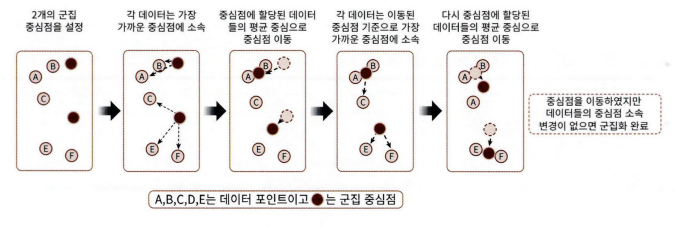

<K평균의 장점>
- 일반벅인 군집화에서 가장 많이 활용되는 알고리즘
- 알고리즘이 쉽고 간결

<K평균의 단점>
- 거리 기반 알고리즘으로 속성의 개수가 매우 많을 경우 군집화 정확도가 떨어진다.
- 반보글 수행하는데, 반복횟수가 많을 경우 수행시간이 매우 느려진다.
- 몇 개의 군집을 선택해야 할지 가이드하기가 어렵다.

**사이킷런 KMeans 클래스 소개**

In [1]:
#class sklearn.cluster.KMeans(c_clusters=8, init='k-means++',n_init=10, max_iter=300, tol=0.0001,
#                             precompute_distances='auto',verbose=0, random_state=None,
#                             copoy_x=True, n_jobs=1, algorithm='auto')

중요한 파라미터
- n_clusters: 군집화할 개수, 즉 군집 중심점의 개수를 의미
- init: 초기에 군집 중심점의 좌표를 설정할 방식, 보통은 임의로 중심을 성저하기 않고 일반적으로 k-means++방식으로 최초 설정
- max_iter: 최대 반복 횟수, 이 횟수 이전 모든 데이터의 중심점 이동이 없으면 종료

주요 속성 정보
- labels_: 각 데이터 포인트가 속한 군집 중심점 레이블
- cluster_centers_:각 군집 중심점 좌표, 이를 이용하면 군집 중심점 좌표가 어디인지 시각화할 수 있음

In [2]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
#더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=['Sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head(3)

,Sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [4]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


labels_의 값이 0,1,2로 되어 있으며, 이는 각 레코드가 첫 번째 군집, 두 번째 군집, 세 번째 군집에 속함을 의미한다.

붓꽃 데이터 세트의 target 값을 target칼럼으로, 앞에서 구한 labels_ 값을 cluster칼럼으로 지정해 irisDF DataFrame에 추가한 뒤에 group by 연산을 실제 분류값인 target과 군집화 분류값인 cluster레벨로 적용해 target과 cluster 값 개수를 비교할 수 있다.

In [5]:
irisDF['target']=iris.target
irisDF['cluster'] = kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['Sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: Sepal_length, dtype: int64


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:,0]
irisDF['pca_y'] = pca_transformed[:,1]
irisDF.head(3)

,Sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


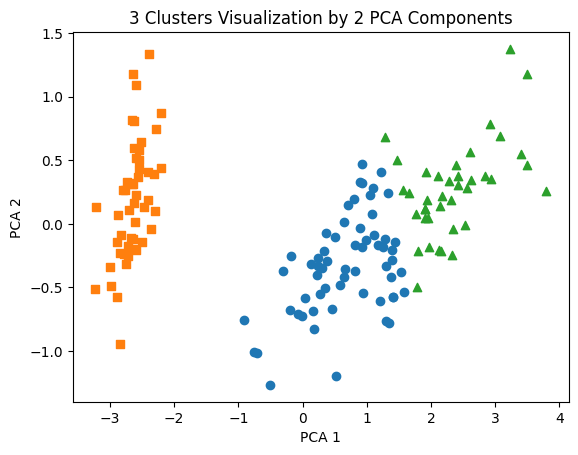

In [7]:
#군집 값이 0,1,2인 경우마다 별도의 인덱스로 추출
marker0_ind = irisDF[irisDF['cluster']==0].index
marker1_ind = irisDF[irisDF['cluster']==1].index
marker2_ind = irisDF[irisDF['cluster']==2].index

#군집 값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o,s,^로 마커 표시
plt.scatter(x=irisDF.loc[marker0_ind,'pca_x'], y=irisDF.loc[marker0_ind,'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind,'pca_x'], y=irisDF.loc[marker1_ind,'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind,'pca_x'], y=irisDF.loc[marker2_ind,'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

**군집화 알고리즘 테스트를 위한 데이터 생성**

대표적인 군집화용 데이터 생성기로는 make_blobs()와 make_classification() API가 있다.

```make_blobs```: 개별 군집 중심점과 표준 편차 제어 기능이 추가되어 있음

```make_classification```:노이즈를 포함한 데이터를 만드는 데 유용하게 사용할 수 있다.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X,y= make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)

# y target값의 분포를 확인
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [9]:
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


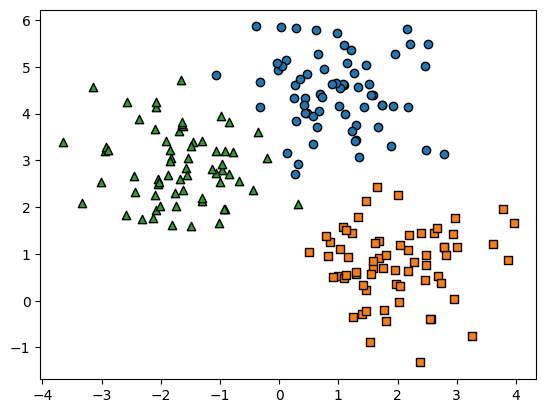

In [10]:
target_list = np.unique(y)
#각 타깃별 산점도의 마커 값
markers=['o','s','^','P','D','H','x']
#3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0,1,2]
# target==0, target==1, target==2로 scatter plot을 marker별로 생성
for target in target_list:
  target_cluster = clusterDF[clusterDF['target']==target]
  plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k',marker=markers[target])

plt.show()

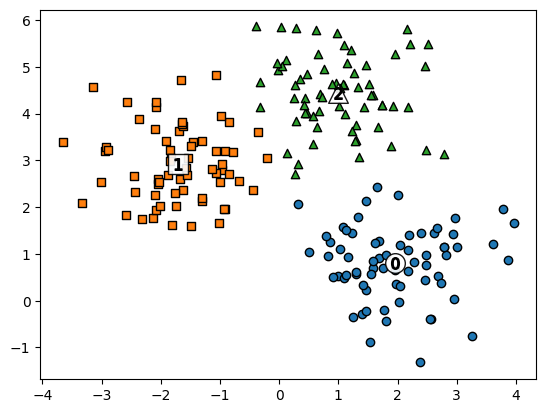

In [11]:
#KMeans 객체를 이용해 x데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

#cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_lables = np.unique(cluster_labels)
markers = ['o','s','^','P','D','H','x']

#군집된 label 유형별로 iteration하면서 marker별로 scatter plot 수행
for label in unique_lables:
  label_cluster = clusterDF[clusterDF['kmeans_label']==label]
  center_x_y = centers[label]
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

  #군집별 중심 위치 좌표 시각화
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white',
              alpha=0.9, edgecolor='k', marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$'%label)

plt.show()

In [12]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


make_blobs()은 cluster_std파라미터로 데이터의 분포도를 조정한다.

### 02. **군집평가**

군집화의 성능을 평가하는 대표적인 방법으로 **실루엣 분석**이 있다.

**실루엣 분석의 개요**

각 군집 간의 거리가 얼마나 효율적으로 분리되어 있는지를 나타낸다. 효율적으로 잘 분리됐다는 것은 다른 군집과의 거리는 떨어져 있고 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐 있다는 의미이다. 군집화가 잘될수록 개별 군집은 비슷한 정도의 여유공간을 가지고 떨어져 있을 것이다.

실루엣 계수를 기반으로 하며 실루엣 계수는 개별 데이터가 가지는 군집화 지표이다. 개별 데이터가 가지는 실루엣 계수는 해당 데이터가 같은 군집내의 데이터와 얼마나 가깝게 군집화돼 있고, 다른 군집에 있는 데이터와 얼마나 멀리 분리되어 있는지 나타내는 지표이다.

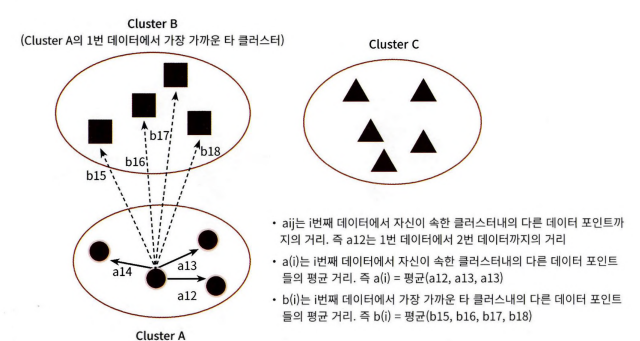

실루엣 계수 $s(i)$는 다음과 같이 정의한다.
$$ s(i) = \frac{b(i)-a(i)}{max(a(i),b(i))}$$

실루엣 계수는 -1에서 1사이의 값을 가지며, 1로 가까워질수록 근처의 군집과 더 멀리 떨어져 있다는 것이고 0에 가까울수록 근처의 군집과 가까워짐을 의미

음수 값은 아예 다른 군집에 데이터 포인트가 할당됐음을 뜻한다.

- 좋은 군집화의 기준 조건
1. 전체 실루엣 계수의 평균값, 즉 사이킷런의 silhoutte_core()값은 0~1사이의 값을 가지며, 1에 가까울수록 좋다
2. 하지만 전체 실루엣 계수의 평균값과 더불어 개별 군집의 평균값의 편차가 크지 않아야 한다. 즉, 개별 군집의 실루엣 계수 평균값이 전체 실루엣 계수의 평균값에서 크게 벗어나지 않는 것이 중요하다.

**붓꽃 데이터 세트를 이용한 군집 평가**

In [13]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

#실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

iris = load_iris()
feature_names = ['Sepal_length','Sepal_length','Petal_length','Petal_width']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

#iris의 모든 개별 데이터에 실루엣 계수 값을 구함
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape', score_samples.shape)

#irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff'] = score_samples

#모든 데이터의 평균 실루엣 계수 값을 구함
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score:0.551


,Sepal_length,Sepal_length,Petal_length,Petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [14]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


**군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법**

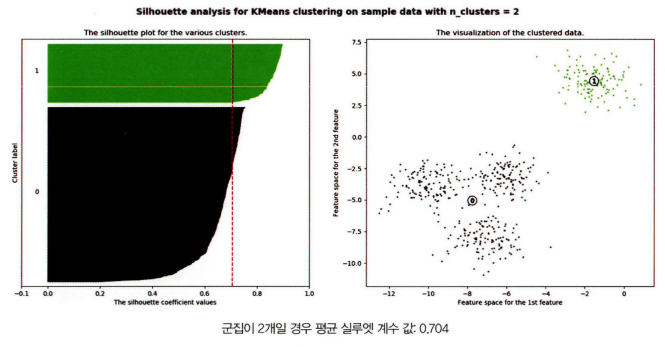

왼쪽 그림은 개별 군집에 속하는 데이터의 실루엣 계수를 2차원으로 나타낸 것이다. X축은 실루엣 계수 값이고, Y축은 개별 군집과 이에 속하는 데이터이다. 개별 군집은 Y축에 숫자값으로 0,1로 표시돼 있다. 점선으로 표시된 선은 전체 평균 실루엣 계수 값을 나타낸다.

이로 판단해 볼 때, 1번 군집의 모든 데이터는 평균 실루엣 계수 값 이상이지만, 2번 군집의 경우 평균보다 적은 데이터 값이 매우 많다.

그 이유는 오른쪽 그림으로 설명할 수 있다.
1번 군집의 경우, 0번과 멀리 떨어져 있고, 내부 데이터끼리도 잘 뭉쳐 있다. 하지만 0번의 경우 내부 데이터끼리 많이 떨어져 있는 모습이다.

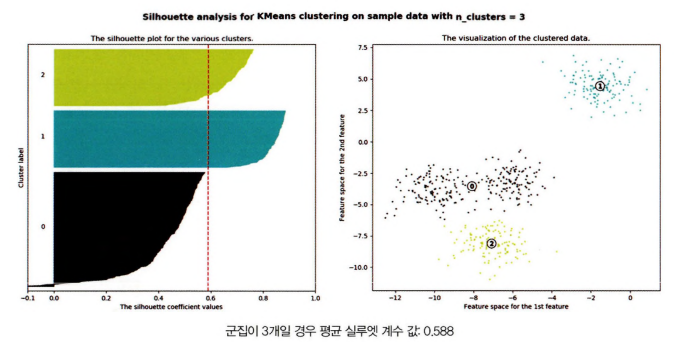

위 그림은 군집 개수가 3개인 경우이다. 전체 데이터 평균 실루엣 계수 값은 약 0.588이다. 1번, 2번 군집의 경우 평균보다 높은 실루엣 계수 값을 가지고 있지만, 0번의 경우 모두 평균보다 낮다.

오른쪽 그림을 보면 0번의 경우 내부 데이터 간의 거리도 멀지만, 2번 군집과도 가깝게 위치하고 있기 때문이다.

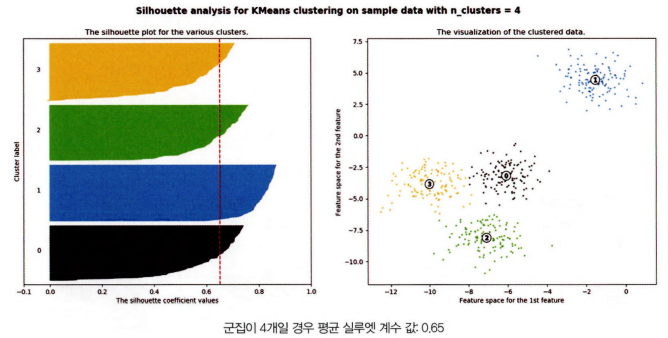

군집이 4개인 경우 평균 실루엣 계수값은 약 0.65이다. 왼쪽 그림에서 보이듯 개별 군집의 평균 실루엣 계수값이 비교적 균일하게 위치하고 있다. 1번의 경우 모든 데이터가 평ㄱㄴ보다 높은 계수 값을 가지고 있으며, 0번, 2번의 경우 절반 이상이 평균보다 높은 계수값을, 3번의 경우 약 $\frac{1}{3}$정도가 평균보다 높은 계수 값을 가진다. 군집이 2개인 경우보다는 평균 실루엣 계수 값이 작지만 4개인 경우가 **가장 이상적인 군집화 개수**로 판단할 수 있다.

In [ ]:
# visualize_silhouette([2,3,4,5], X_features)

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_silhouette(cluster_list,X):
  from matplotlib import pyplot as plt

  for n_clusters in cluster_list:
    fig, ax1 = plt.subplots(1)
    fig.set_size_inches(6,4)

    ax1.set_xlim([-0.1,1])
    ax1.set_ylim([0,len(X)+(n_clusters+1)*10])

    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(X)

    silhouette_vals = silhouette_samples(X, cluster_labels)
    silhouette_avg = silhouette_score(X, cluster_labels)

    y_lower = 10

    for i in range(n_clusters):
      ith_silhouette_vals = silhouette_vals[cluster_labels == i]
      ith_silhouette_vals.sort()

      size_cluster_i = ith_silhouette_vals.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.nipy_spectral(float(i) / n_clusters)
      ax1.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_silhouette_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    plt.tight_layout()
    plt.show()

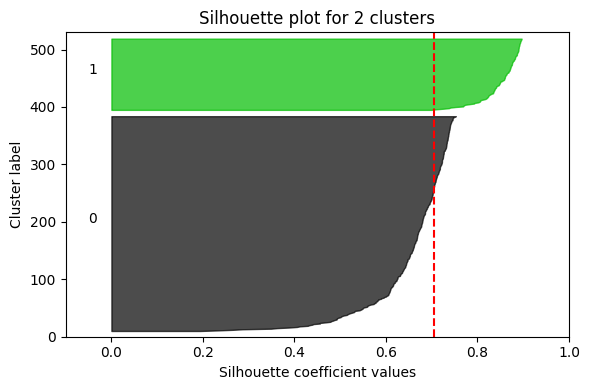

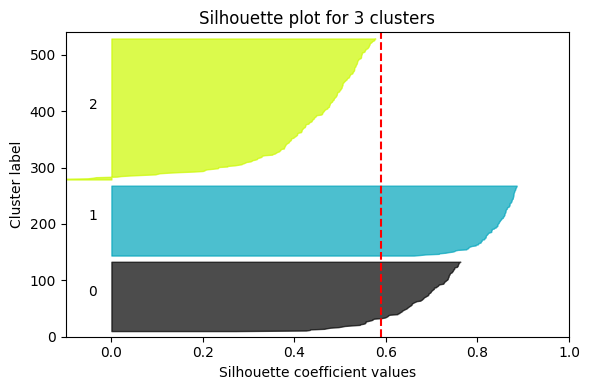

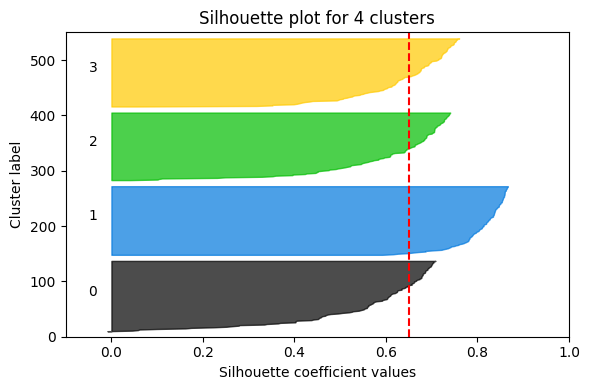

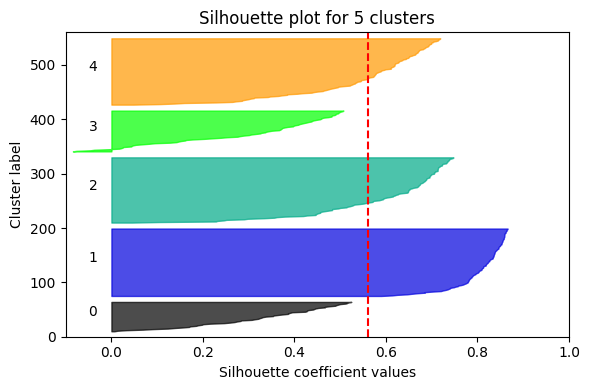

In [17]:
#make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1,
                 center_box=(-10.0,10.0), shuffle=True, random_state=1)

#군집 개수가 2개, 3개, 4개, 5개일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([2,3,4,5],X)
#하나의 캔버스에 나타내기
plt.subplot

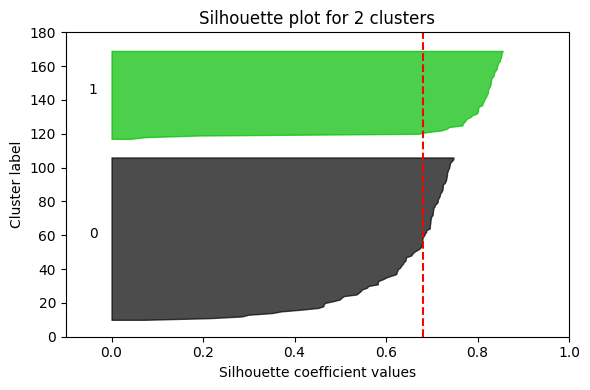

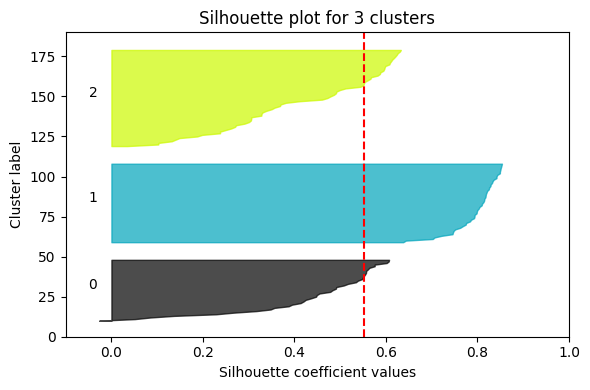

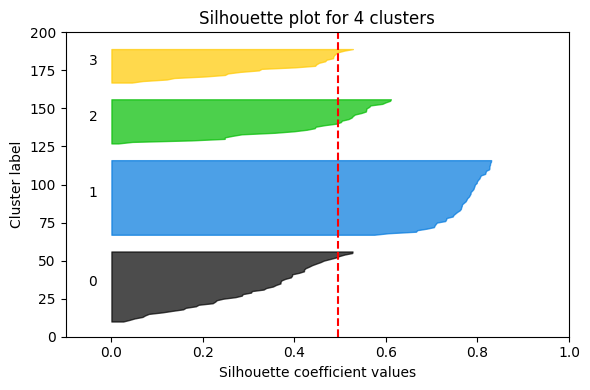

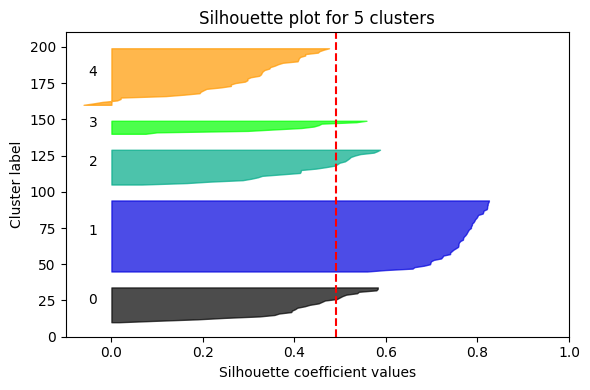

In [18]:
from sklearn.datasets import load_iris
iris = load_iris()
visualize_silhouette([2,3,4,5], iris.data)

붓꽃 데이터를 K-평균으로 군집화할 경우 군집 개수를 2개로 하는 것이 가장 좋아보인다. 3개의 경우 평균 실루엣 계수 값도 2개보다 작을 뿐더러 1번 군집과 다른 0번, 2번 군집과의 실루엣 계수의 편차가 크다. 4개, 5개의 경우도 마찬가지이다.

실루엣 계수를 통한 K-평균 군집 평가 방법은 직관적으로 이해하기 쉽지만, 각 데이터별로 다른 데이터와의 거리를 반복적으로 계산해야 하므로 데이터양이 늘어나면 수행시간이 크게 늘어난다. 이때 군집별로 임의의 데이터를 샘플링해 실루엣 계수를 평가하는 방안을 고민해야 한다.